# 03 Surface Water Reliability

**Series:** Pine Ridge Hydrology                                                 
**Author:** Lilly Jones, PhD                             
**Primary Focus:** Pine Ridge Reservation/Oglala Sioux Tribe                                                
**Collective:** Oglala Lakota                                                               
**Data Sources:** USGS NWIS streamflow                                                        

## Surface Water on Oglala Lakota Lands

The White River is the primary surface water drainage through Pine Ridge
and Pine Ridge. It is a prairie river that is naturally episodic, with flows
ranging from flood stage to near-zero in dry summers.

This is the natural hydrology of the Northern
Great Plains. But it means surface water cannot be relied on as a
consistent source for domestic or livestock supply, and that drought
years significantly reduce the already limited surface water available.

## Research Questions
- What fraction of the year does the White River maintain baseflow?
- How does flow reliability vary across drought vs. wet years?
- What is the long-term trend in low-flow conditions?
- How does the 7-day minimum flow (7Q10 proxy) compare to
  ecologically and culturally meaningful thresholds?

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
from io import StringIO

from src.constants import (
    CRS_GEOGRAPHIC, REPO_ROOT as _REPO_ROOT,
    OUTPUTS_DIR, FIGURES_DIR,
)
from src.config import load_config, streamflow_site_ids, streamflow_site_names

CONFIG = load_config()
STUDY_BBOX = tuple(CONFIG["study_area"]["hydrologic_context_bbox"])
STUDY_NAMES = [CONFIG["study_area"]["people"]]
STUDY_CENTROIDS = {CONFIG["study_area"]["people"]: CONFIG["study_area"]["centroid"]}
PINE_RIDGE_STREAMGAGES = {
    site["name"]: str(site["id"]) for site in CONFIG["usgs_streamflow_sites"]
}

from src.indicators import (
    compute_baseflow,
    classify_drought_stage,
    compute_flow_reliability,
    theilsen_trend,
)
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

with open(_REPO_ROOT / "config" / "config.yaml") as f:
    CONFIG = yaml.safe_load(f)

THRESHOLDS = CONFIG["thresholds"]["streamflow"]
SITE_IDS   = streamflow_site_ids(CONFIG)
START_YEAR = CONFIG["analysis"]["start_year"]
END_YEAR   = CONFIG["analysis"]["end_year"]

print(f"Streamflow sites : {SITE_IDS}")
print(f"Analysis period  : {START_YEAR}–{END_YEAR}")
print(f"Emergency threshold: {THRESHOLDS['emergency_cfs']} cfs")
print(f"Watch threshold    : {THRESHOLDS['watch_cfs']} cfs")

Streamflow sites : ['06445685', '06446000', '06446700', '06446500', '06447000', '06447500', '06449100', '06449000']
Analysis period  : 2000–2024
Emergency threshold: 5 cfs
Watch threshold    : 20 cfs


In [2]:
# Print data acknowledgement
print_data_acknowledgment(source_keys=["usgs_nwis_streamflow", "census_aiannh"])


TRIBAL WATER MONITORING DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses public data that describes the lands and waters of the
Pine Ridge Reservation and Oglala Lakota communities. This draft statement
has not been approved by the OST Research Review Board or OLC Institutional
Review Board.

INTERIM REVIEW CONTACT
  Camille Griffith, PhD, Director, OST RRB and OLC IRB
  cgriffith@olc.edu

  Listing the contact does not indicate approval of this analysis.

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE addresses responsibilities that
  FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Practice for Provenance of Indig

## Load Streamflow Data

The loader below is self-contained and does not depend on `loaders.py` (WIP to integrate)
It handles the current NWIS RDB column format (`{TS_ID}_00060_00003`) correctly.

In [3]:
from src.constants import CACHE_DIR

def load_streamflow_nwis(site_ids, start_date="2000-01-01", end_date="2024-12-31",
                          force_refresh=False):
    cache_key  = f"nwis_flow_{'_'.join(sorted(site_ids))}_{start_date[:4]}_{end_date[:4]}.csv"
    cache_file = CACHE_DIR / cache_key

    if cache_file.exists() and not force_refresh:
        df = pd.read_csv(cache_file, parse_dates=["datetime"])
        print(f"Loaded from cache: {len(df):,} records")
        return df

    r = requests.get(
        "https://waterservices.usgs.gov/nwis/dv/",
        params={
            "format":      "rdb",
            "sites":       ",".join(site_ids),
            "startDT":     start_date,
            "endDT":       end_date,
            "parameterCd": "00060",
            "statCd":      "00003",
        },
        timeout=120,
    )
    r.raise_for_status()

    lines = [l for l in r.text.splitlines() if not l.startswith("#")]
    if len(lines) < 3:
        warnings.warn("NWIS returned no data rows.", UserWarning)
        return pd.DataFrame()

    header     = lines[0].split("\t")
    data_lines = [l for l in lines[2:] if l.strip() and l.startswith("USGS")]

    if not data_lines:
        warnings.warn(
            f"No USGS data rows for sites {site_ids}.",
            UserWarning,
        )
        return pd.DataFrame()

    df = pd.read_csv(
        StringIO("\n".join(data_lines)),
        sep="\t", header=None, names=header, dtype=str,
    )

    val_col = next(
        (c for c in df.columns if "00060" in c and not c.endswith("_cd")),
        None,
    )
    if val_col is None:
        warnings.warn(f"No flow value column found. Columns: {header}", UserWarning)
        return pd.DataFrame()

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["flow_cfs"]  = pd.to_numeric(df[val_col], errors="coerce")
    df = df[["site_no", "datetime", "flow_cfs"]].dropna(subset=["datetime"]).reset_index(drop=True)

    df.to_csv(cache_file, index=False)
    print(f"Downloaded and cached: {len(df):,} records")
    return df


flow_df = load_streamflow_nwis(
    site_ids   = SITE_IDS,
    start_date = f"{START_YEAR}-01-01",
    end_date   = f"{END_YEAR}-12-31",
)

if flow_df.empty:
    print("No streamflow data returned.")
    print("Check USGS site IDs in config/config.yaml")
    print("Find gauges: https://waterdata.usgs.gov/nwis")
else:
    print(f"Streamflow records: {len(flow_df):,}")
    print(f"Sites: {flow_df['site_no'].unique().tolist()}")
    print(f"Date range: {flow_df['datetime'].min().date()} to "
          f"{flow_df['datetime'].max().date()}")
    print(f"\nFlow statistics (cfs):")
    print(flow_df.groupby("site_no")["flow_cfs"].describe().round(2).to_string())

Downloaded and cached: 72,052 records
Streamflow records: 72,052
Sites: ['06445685', '06446000', '06446500', '06446700', '06447000', '06447500', '06449000', '06449100']
Date range: 2000-01-01 to 2024-12-31

Flow statistics (cfs):
           count    mean     std    min    25%    50%    75%      max
site_no                                                              
06445685  9132.0   50.06  159.11   0.00   7.30  16.95   43.9   4230.0
06446000  9132.0   76.72  270.27   0.00   8.64  25.80   63.0   5960.0
06446500  8128.0  231.90  704.82   0.00  24.60  65.00  166.0  15600.0
06446700  9132.0   20.35   54.96   0.00   7.00  12.00   20.9   2480.0
06447000  9132.0  303.58  869.95   0.00  30.00  83.00  227.0  16800.0
06447500  9132.0   26.13   37.80   2.47  11.20  17.00   28.8   1250.0
06449000  9132.0   27.43   22.61   0.00  10.30  23.20   37.1    200.0
06449100  9132.0   74.64   68.72  11.70  40.00  55.60   91.8   2340.0


## Baseflow Separation

In [4]:
if not flow_df.empty:
    # Add station names
    site_to_name = {v: k for k, v in PINE_RIDGE_STREAMGAGES.items()}

    # Run baseflow separation for each site independently
    bf_parts = []
    for site_no, grp in flow_df.groupby("site_no"):
        grp = grp.sort_values("datetime").copy()
        grp = compute_baseflow(grp, flow_col="flow_cfs")
        bf_parts.append(grp)

    flow_df = pd.concat(bf_parts, ignore_index=True)
    flow_df["station_name"] = flow_df["site_no"].map(site_to_name)
    flow_df["reservation"]  = flow_df["site_no"].apply(
        lambda s: "Pine Ridge" if s in list(PINE_RIDGE_STREAMGAGES.values())
                  else "Pine Ridge hydrologic context"
    )

    # Summary table across all sites
    summary = (
        flow_df.groupby(["site_no", "station_name", "reservation"])
        .agg(
            mean_flow_cfs    = ("flow_cfs",       "mean"),
            mean_baseflow_cfs= ("baseflow_cfs",   "mean"),
            mean_bfi         = ("baseflow_index", "mean"),
            n_days           = ("flow_cfs",       "count"),
        )
        .round(3)
        .reset_index()
        .sort_values(["reservation", "mean_bfi"])
    )

    print("BASEFLOW ANALYSIS for All Gauges")
    print(f"{'Station':<45} {'Resv':>10} {'Flow':>8} {'BF':>8} {'BFI':>6}")
    for _, row in summary.iterrows():
        name = row["station_name"][:43]
        bfi_label = (
            "LOW"  if row["mean_bfi"] < 0.3 else
            "MOD"  if row["mean_bfi"] < 0.6 else
            "HIGH"
        )
        print(f"  {name:<43} {row['reservation']:>10} "
              f"{row['mean_flow_cfs']:>7.1f} "
              f"{row['mean_baseflow_cfs']:>7.1f} "
              f"{row['mean_bfi']:>5.3f} {bfi_label}")

    print()
    overall_bfi = flow_df["baseflow_index"].mean()
    print(f"Overall mean BFI across all sites: {overall_bfi:.3f}")
    print()
    if overall_bfi < 0.3:
        print("  Low BFI: streams are predominantly runoff-driven.")
        print("  Flow is episodic and not a reliable year-round supply.")
    elif overall_bfi < 0.6:
        print("  Moderate BFI: mixed groundwater and runoff contributions.")
        print("  Streams have some baseflow but are vulnerable to drought.")
    else:
        print("  High BFI: streams are predominantly groundwater-fed.")
        print("  Relatively reliable baseflow but sensitive to aquifer depletion.")

BASEFLOW ANALYSIS for All Gauges
Station                                             Resv     Flow       BF    BFI
  White River near Interior, SD               Pine Ridge   231.9    98.4 0.736 HIGH
  White River near Kadoka, SD                 Pine Ridge   303.6   129.3 0.742 HIGH
  White River near Nebraska-South Dakota stat Pine Ridge    50.1    30.2 0.810 HIGH
  White River near Oglala, SD                 Pine Ridge    76.7    47.7 0.814 HIGH
  Lake Creek below refuge near Tuthill, SD    Pine Ridge    27.4    23.4 0.819 HIGH
  Bear in the Lodge Creek near Wanblee, SD    Pine Ridge    20.4    14.6 0.852 HIGH
  Little White River near Martin, SD          Pine Ridge    26.1    20.4 0.878 HIGH
  Little White River near Vetal, SD           Pine Ridge    74.6    64.3 0.900 HIGH

Overall mean BFI across all sites: 0.820

  High BFI: streams are predominantly groundwater-fed.
  Relatively reliable baseflow but sensitive to aquifer depletion.


## Flow Reliability Index

In [5]:
if not flow_df.empty:
    # Ensure lookup dict is available regardless of cell run order
    site_to_name = {v: k for k, v in PINE_RIDGE_STREAMGAGES.items()}

    # Compute reliability per site
    rel_parts = []
    for site_no, grp in flow_df.groupby("site_no"):
        rel = compute_flow_reliability(grp, flow_col="flow_cfs", threshold_cfs=1.0)
        rel["site_no"]      = site_no
        rel["station_name"] = site_to_name.get(site_no, site_no)
        rel["reservation"]  = (
            "Pine Ridge" if site_no in list(PINE_RIDGE_STREAMGAGES.values())
            else "Pine Ridge hydrologic context"
        )
        rel_parts.append(rel)

    reliability_all = pd.concat(rel_parts, ignore_index=True)

    site_rel = (
        reliability_all.groupby(["site_no", "station_name", "reservation"])
        ["reliability"].mean()
        .round(3)
        .reset_index()
        .sort_values("reliability")
    )

    print("FLOW RELIABILITY BY GAUGE (mean fraction of year with flow > 1 cfs)")
    for _, row in site_rel.iterrows():
        name = str(row["station_name"])[:42]
        bar  = "█" * int(row["reliability"] * 30)
        print(f"  {name:<42} {row['reliability']:.3f}  {bar}")

    annual_network = (
        reliability_all.groupby("year")["reliability"]
        .mean()
        .reset_index()
        .rename(columns={"reliability": "network_reliability"})
    )

    worst_5  = annual_network.nsmallest(5, "network_reliability")
    best_5   = annual_network.nlargest(5,  "network_reliability")
    mean_rel = annual_network["network_reliability"].mean()

    print(f"\nNetwork-wide mean reliability: {mean_rel:.3f} "
          f"({mean_rel*100:.1f}% of gauge-days with detectable flow)")
    print(f"\nLowest reliability years (driest across all gauges):")
    print(worst_5.to_string(index=False))
    print(f"\nHighest reliability years (wettest across all gauges):")
    print(best_5.to_string(index=False))

    reliability = reliability_all

FLOW RELIABILITY BY GAUGE (mean fraction of year with flow > 1 cfs)
  White River near Oglala, SD                0.900  ███████████████████████████
  White River near Nebraska-South Dakota sta 0.929  ███████████████████████████
  White River near Interior, SD              0.941  ████████████████████████████
  Lake Creek below refuge near Tuthill, SD   0.950  ████████████████████████████
  White River near Kadoka, SD                0.971  █████████████████████████████
  Bear in the Lodge Creek near Wanblee, SD   0.984  █████████████████████████████
  Little White River near Martin, SD         1.000  ██████████████████████████████
  Little White River near Vetal, SD          1.000  ██████████████████████████████

Network-wide mean reliability: 0.960 (96.0% of gauge-days with detectable flow)

Lowest reliability years (driest across all gauges):
 year  network_reliability
 2007             0.831849
 2006             0.835274
 2012             0.836066
 2008             0.852801
 2002     

## Drought Stage Classification

In [6]:
if not flow_df.empty:
    # Classify drought stage for every site
    stage_parts = []
    for site_no, grp in flow_df.groupby("site_no"):
        grp = grp.copy()
        grp = classify_drought_stage(
            grp,
            flow_col      = "flow_cfs",
            normal_cfs    = THRESHOLDS["normal_cfs"],
            watch_cfs     = THRESHOLDS["watch_cfs"],
            emergency_cfs = THRESHOLDS["emergency_cfs"],
        )
        stage_parts.append(grp)

    flow_df = pd.concat(stage_parts, ignore_index=True)

    # Network-wide stage distribution
    stage_counts = flow_df["drought_stage"].value_counts()
    stage_pct    = (stage_counts / len(flow_df) * 100).round(1)

    print("DROUGHT STAGE DISTRIBUTION for All Gauges Combined")
    print(f"  Thresholds: Emergency < {THRESHOLDS['emergency_cfs']} cfs | "
          f"Watch < {THRESHOLDS['watch_cfs']} cfs | "
          f"Normal >= {THRESHOLDS['normal_cfs']} cfs")
    print()
    for stage in ["Emergency", "Watch", "Normal"]:
        n   = stage_counts.get(stage, 0)
        pct = stage_pct.get(stage, 0.0)
        bar = "█" * int(pct / 2)
        print(f"  {stage:<12}: {n:>6} days ({pct:>5.1f}%)  {bar}")

    print()

    
    # Per-site emergency day counts shows which gauges are most stressed
    emerg_counts = (
        flow_df[flow_df["drought_stage"] == "Emergency"]
        .groupby(["site_no", "station_name", "reservation"])
        .size()
        .reset_index()
        .rename(columns={0: "emergency_days"})
        .sort_values("emergency_days", ascending=False)
    )

    # Fill in sites with zero emergency days
    all_sites = flow_df[["site_no","station_name","reservation"]].drop_duplicates()
    site_emerg = all_sites.merge(emerg_counts, on=["site_no","station_name","reservation"], how="left")
    site_emerg["emergency_days"] = site_emerg["emergency_days"].fillna(0).astype(int)
    site_emerg = site_emerg.sort_values("emergency_days", ascending=False)

    print("EMERGENCY DAYS BY GAUGE (total record)")
    for _, row in site_emerg.iterrows():
        name = str(row["station_name"])[:42]
        print(f"  {name:<42} {row['emergency_days']:>5} days  [{row['reservation']}]")


    print()
    print("NOTE: Review thresholds with Tribal water staff.")
    print("What counts as Watch and Emergency for each specific gauge?")

DROUGHT STAGE DISTRIBUTION for All Gauges Combined
  Thresholds: Emergency < 5 cfs | Watch < 20 cfs | Normal >= 50 cfs

  Emergency   :   7965 days ( 11.1%)  █████
  Watch       :  21011 days ( 29.2%)  ██████████████
  Normal      :  43076 days ( 59.8%)  █████████████████████████████

EMERGENCY DAYS BY GAUGE (total record)
  White River near Nebraska-South Dakota sta  1714 days  [Pine Ridge]
  White River near Oglala, SD                 1594 days  [Pine Ridge]
  Bear in the Lodge Creek near Wanblee, SD    1544 days  [Pine Ridge]
  Lake Creek below refuge near Tuthill, SD    1220 days  [Pine Ridge]
  White River near Interior, SD                992 days  [Pine Ridge]
  White River near Kadoka, SD                  788 days  [Pine Ridge]
  Little White River near Martin, SD           113 days  [Pine Ridge]
  Little White River near Vetal, SD              0 days  [Pine Ridge]

NOTE: Review thresholds with Tribal water staff.
What counts as Watch and Emergency for each specific gauge?


## Long-Term Trend in Low Flows

In [7]:
if not flow_df.empty:
    # Ensure year column exists
    flow_df["year"] = pd.to_datetime(flow_df["datetime"]).dt.year

    # 7-day minimum flow per site (rolling min within each site)
    q7_parts = []
    for site_no, grp in flow_df.groupby("site_no"):
        grp = grp.sort_values("datetime").copy()
        grp["7day_min"] = grp["flow_cfs"].rolling(7, min_periods=4).min()
        q7_parts.append(grp)
    flow_df = pd.concat(q7_parts, ignore_index=True)

    # Network annual 7Q: mean of per-site annual minimums across all gauges
    annual_7q_by_site = (
        flow_df.groupby(["year", "site_no"])["7day_min"].min().reset_index()
    )
    annual_7q = (
        annual_7q_by_site.groupby("year")["7day_min"]
        .mean()
        .reset_index()
        .rename(columns={"7day_min": "annual_7q_min"})
    )

    # Network annual emergency days: total across all gauges per year
    annual_emerg = (
        flow_df[flow_df["drought_stage"] == "Emergency"]
        .groupby("year")
        .size()
        .reset_index()
        .rename(columns={0: "emergency_days"})
    )
    # Fill years with zero emergency days
    all_years = pd.DataFrame({"year": flow_df["year"].unique()})
    annual_emerg = all_years.merge(annual_emerg, on="year", how="left")
    annual_emerg["emergency_days"] = annual_emerg["emergency_days"].fillna(0).astype(int)

    # Network annual reliability: mean across sites per year
    annual_rel = (
        reliability.groupby("year")["reliability"]
        .mean()
        .reset_index()
        .rename(columns={"reliability": "network_reliability"})
    )

    # Combine
    annual_summary = (
        annual_7q
        .merge(annual_emerg, on="year")
        .merge(annual_rel,   on="year", how="left")
        .sort_values("year")
    )

    # Trend analysis
    trend_7q = theilsen_trend(
        annual_summary["annual_7q_min"].values,
        annual_summary["year"].values,
    )
    trend_emerg = theilsen_trend(
        annual_summary["emergency_days"].values.astype(float),
        annual_summary["year"].values,
    )

    print("LONG-TERM TREND ANALYSIS Network Wide (all gauges)")
    print(f"  Annual 7-day minimum flow (mean across gauges):")
    print(f"    Trend: {trend_7q['slope_per_decade']:+.3f} cfs/decade "
          f"({'significant' if trend_7q['significant'] else 'not significant'}, "
          f"p={trend_7q['p_value']:.3f})")
    print()
    print(f"  Annual emergency-stage gauge-days (sum across network):")
    print(f"    Trend: {trend_emerg['slope_per_decade']:+.1f} days/decade "
          f"({'significant' if trend_emerg['significant'] else 'not significant'}, "
          f"p={trend_emerg['p_value']:.3f})")
    print()
    print("  Annual summary (last 5 years):")
    print(annual_summary.tail(5).to_string(index=False))

LONG-TERM TREND ANALYSIS Network Wide (all gauges)
  Annual 7-day minimum flow (mean across gauges):
    Trend: +0.666 cfs/decade (not significant, p=0.441)

  Annual emergency-stage gauge-days (sum across network):
    Trend: -77.8 days/decade (not significant, p=0.199)

  Annual summary (last 5 years):
 year  annual_7q_min  emergency_days  network_reliability
 2020       10.78250              39             0.995902
 2021        4.92000             366             0.967123
 2022        2.06125             720             0.945890
 2023        4.07625              82             0.997945
 2024        3.37625             466             0.956626


## Visualizations

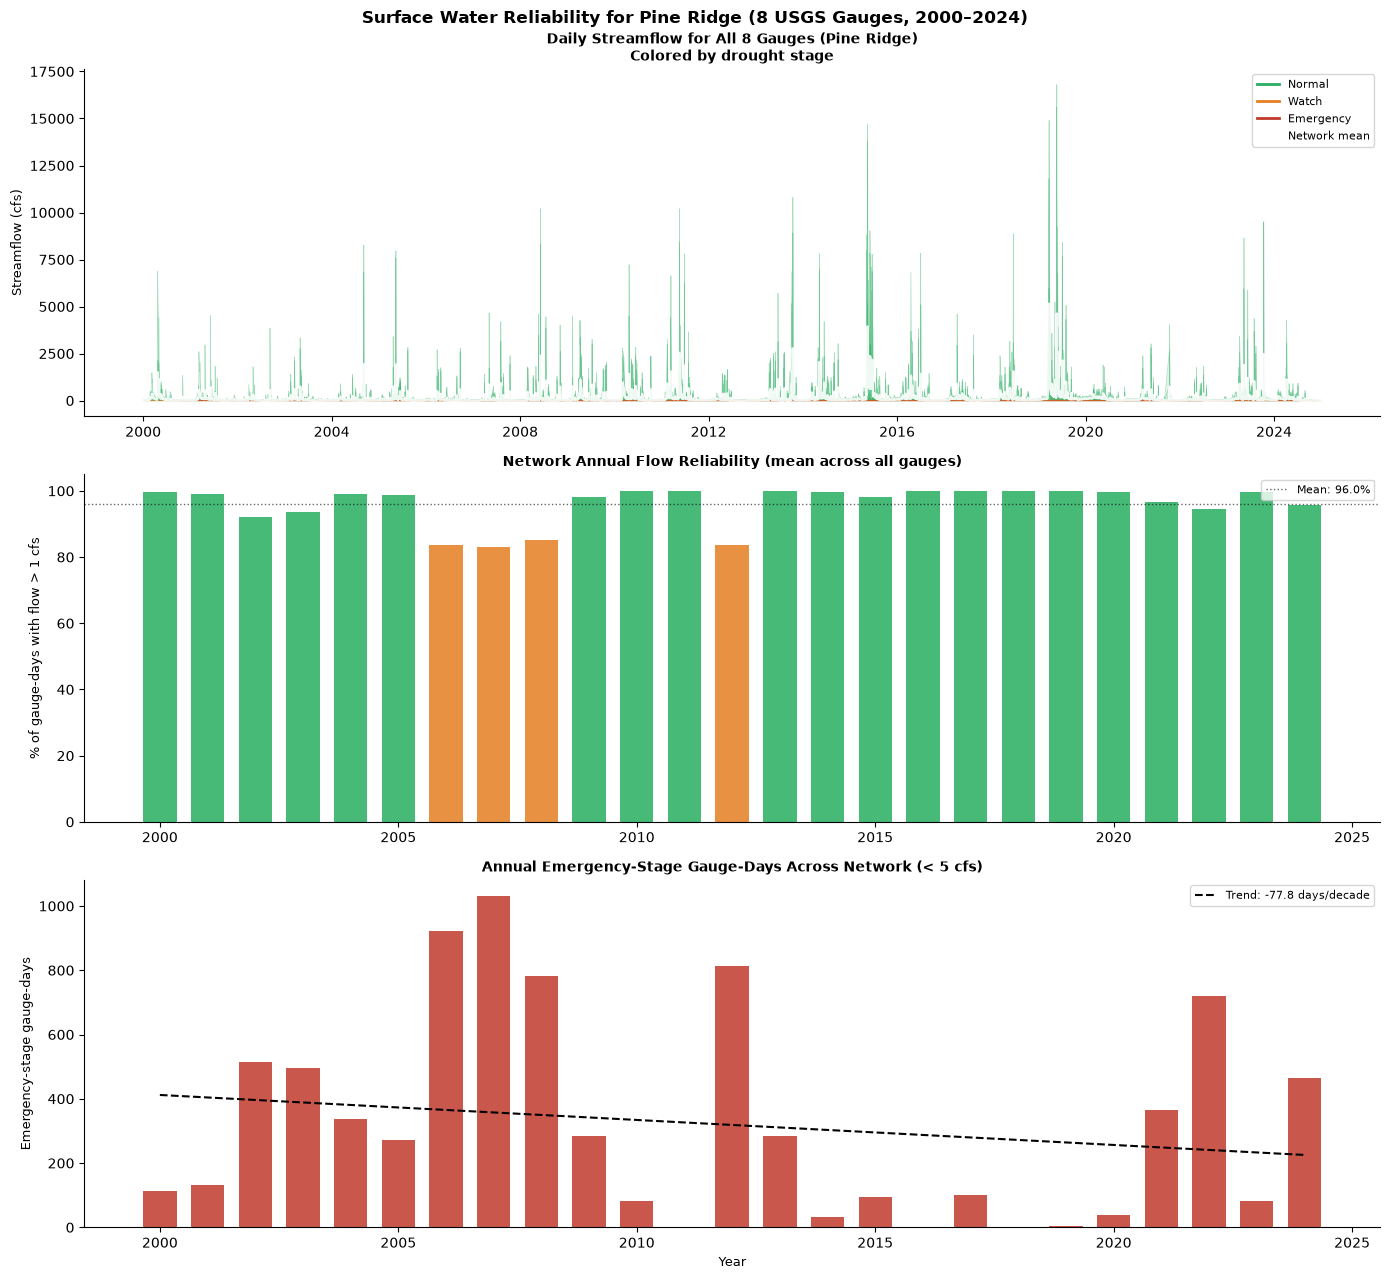

In [8]:
if not flow_df.empty:
    fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)
    STAGE_COLORS = {"Normal":"#27AE60", "Watch":"#E67E22", "Emergency":"#C0392B"}

    # Network hydrograph all sites, colored by stage
    ax = axes[0]
    # Plot each site as a thin line, colored by median stage that day
    for site_no, grp in flow_df.groupby("site_no"):
        grp = grp.sort_values("datetime")
        for stage, color in STAGE_COLORS.items():
            mask = grp["drought_stage"] == stage
            if mask.any():
                ax.fill_between(
                    grp.loc[mask, "datetime"],
                    grp.loc[mask, "flow_cfs"],
                    alpha=0.15, color=color, linewidth=0,
                )
                ax.plot(
                    grp.loc[mask, "datetime"],
                    grp.loc[mask, "flow_cfs"],
                    color=color, alpha=0.4, linewidth=0.5,
                )

    # Overlay network mean flow as a bold line
    network_daily = (
        flow_df.groupby("datetime")["flow_cfs"]
        .mean()
        .reset_index()
        .sort_values("datetime")
    )
    ax.plot(network_daily["datetime"], network_daily["flow_cfs"],
            color="white", linewidth=1.8, alpha=0.9, label="Network mean")

    legend_patches = [
        plt.Line2D([0],[0], color=c, linewidth=2, label=s)
        for s, c in STAGE_COLORS.items()
    ] + [plt.Line2D([0],[0], color="white", linewidth=2, label="Network mean")]
    ax.legend(handles=legend_patches, fontsize=8, loc="upper right")
    ax.set_ylabel("Streamflow (cfs)", fontsize=9)
    ax.set_title(
        f"Daily Streamflow for All {flow_df['site_no'].nunique()} Gauges "
        f"(Pine Ridge)\nColored by drought stage",
        fontsize=10, fontweight="bold",
    )
    despine(ax)

    # Network annual reliability
    ax = axes[1]
    annual_rel = (
        reliability.groupby("year")["reliability"]
        .mean()
        .reset_index()
    )
    colors_rel = [
        "#27AE60" if v >= 0.9 else "#E67E22" if v >= 0.6 else "#C0392B"
        for v in annual_rel["reliability"]
    ]
    ax.bar(annual_rel["year"], annual_rel["reliability"] * 100,
           color=colors_rel, alpha=0.85, width=0.7)
    ax.axhline(annual_rel["reliability"].mean() * 100, color="black",
               linewidth=1, linestyle=":", alpha=0.6,
               label=f"Mean: {annual_rel['reliability'].mean()*100:.1f}%")
    ax.set_ylabel("% of gauge-days with flow > 1 cfs", fontsize=9)
    ax.set_title("Network Annual Flow Reliability (mean across all gauges)",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    despine(ax)

    # Emergency days trend
    ax = axes[2]
    ax.bar(annual_summary["year"], annual_summary["emergency_days"],
           color="#C0392B", alpha=0.85, width=0.7)
    yrs = annual_summary["year"].values.astype(float)
    trend_line = (trend_emerg["slope"] * yrs
                  + (annual_summary["emergency_days"].mean()
                     - trend_emerg["slope"] * yrs.mean()))
    ax.plot(annual_summary["year"], trend_line, color="black",
            linewidth=1.5, linestyle="--",
            label=f"Trend: {trend_emerg['slope_per_decade']:+.1f} days/decade")
    ax.set_ylabel("Emergency-stage gauge-days", fontsize=9)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_title(
        f"Annual Emergency-Stage Gauge-Days Across Network "
        f"(< {THRESHOLDS['emergency_cfs']} cfs)",
        fontsize=10, fontweight="bold",
    )
    ax.legend(fontsize=8)
    despine(ax)

    plt.suptitle(
        "Surface Water Reliability for Pine Ridge "
        f"({flow_df['site_no'].nunique()} USGS Gauges, {flow_df['year'].min()}–{flow_df['year'].max()})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"03_surface_water_reliability.png",
                    dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

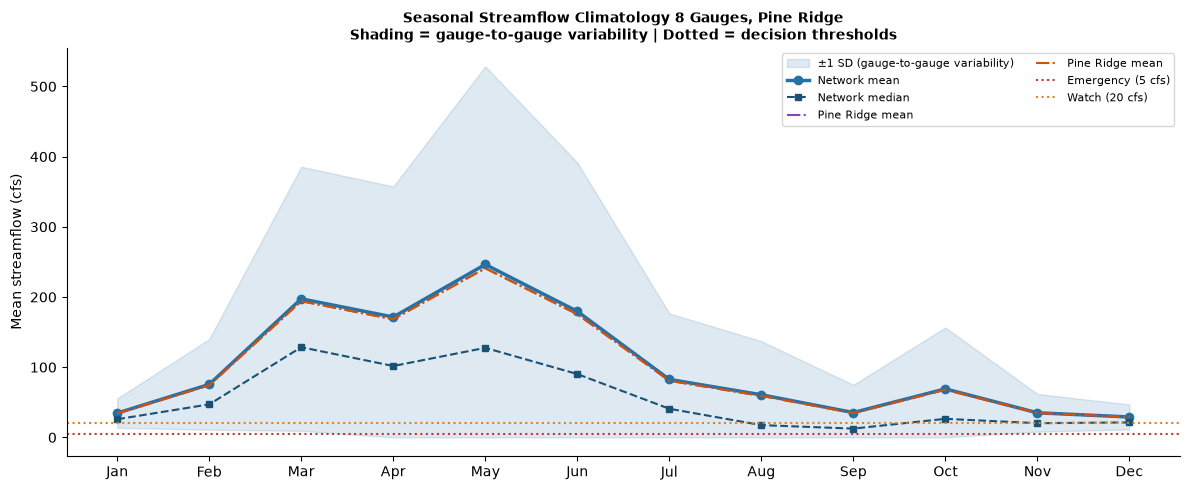

In [9]:
if not flow_df.empty:
    # Ensure datetime-derived columns exist
    flow_df["datetime"] = pd.to_datetime(flow_df["datetime"])
    flow_df["year"]  = flow_df["datetime"].dt.year
    flow_df["month"] = flow_df["datetime"].dt.month

    # Network seasonal climatology mean across all gauges by month
    monthly_clim = (
        flow_df.groupby(["site_no", "month"])["flow_cfs"]
        .mean()
        .reset_index()
        .groupby("month")["flow_cfs"]
        .agg(["mean", "median", "std"])
        .reset_index()
    )

    pr_clim = (
        flow_df[flow_df["reservation"] == "Pine Ridge"]
        .groupby("month")["flow_cfs"].mean()
    )
    rb_clim = (
        flow_df[flow_df["reservation"] == "Pine Ridge"]
        .groupby("month")["flow_cfs"].mean()
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(
        monthly_clim["month"],
        (monthly_clim["mean"] - monthly_clim["std"]).clip(0),
        monthly_clim["mean"] + monthly_clim["std"],
        alpha=0.15, color="#2471A3", label="±1 SD (gauge-to-gauge variability)",
    )
    ax.plot(monthly_clim["month"], monthly_clim["mean"],
            color="#2471A3", linewidth=2.5, marker="o", markersize=6,
            label="Network mean")
    ax.plot(monthly_clim["month"], monthly_clim["median"],
            color="#1A5276", linewidth=1.5, linestyle="--",
            marker="s", markersize=4, label="Network median")
    if not pr_clim.empty:
        ax.plot(pr_clim.index, pr_clim.values,
                color="#8E44AD", linewidth=1.5, linestyle="-.",
                label="Pine Ridge mean")
    if not rb_clim.empty:
        ax.plot(rb_clim.index, rb_clim.values,
                color="#D35400", linewidth=1.5, linestyle="-.",
                label="Pine Ridge mean")

    ax.axhline(THRESHOLDS["emergency_cfs"], color="#C0392B", linewidth=1.5,
               linestyle=":", label=f"Emergency ({THRESHOLDS['emergency_cfs']} cfs)")
    ax.axhline(THRESHOLDS["watch_cfs"], color="#E67E22", linewidth=1.5,
               linestyle=":", label=f"Watch ({THRESHOLDS['watch_cfs']} cfs)")

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])
    ax.set_ylabel("Mean streamflow (cfs)", fontsize=10)
    ax.set_title(
        f"Seasonal Streamflow Climatology {flow_df['site_no'].nunique()} Gauges, "
        f"Pine Ridge\n"
        "Shading = gauge-to-gauge variability | Dotted = decision thresholds",
        fontsize=10, fontweight="bold",
    )
    ax.legend(fontsize=8, ncol=2)
    despine(ax)
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"03_seasonal_flow.png", dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

## All Gauges Overview

Summary statistics for all Pine Ridge gauges defined in `constants.py`.

In [10]:
print("Loading all gauges (Pine Ridge)...")
print("This queries USGS for 15 sites over 24 years. Please wait.\n")

all_flow = load_streamflow_nwis(
    site_ids   = list(PINE_RIDGE_STREAMGAGES.values()),
    start_date = f"{START_YEAR}-01-01",
    end_date   = f"{END_YEAR}-12-31",
)

if not all_flow.empty:
    site_to_name = {v: k for k, v in PINE_RIDGE_STREAMGAGES.items()}
    all_flow["station_name"] = all_flow["site_no"].map(site_to_name)
    summary = (
        all_flow.groupby(["site_no", "station_name"])["flow_cfs"]
        .agg(["count", "mean", "median", "min"])
        .round(2)
        .reset_index()
    )
    summary.columns = ["site_no", "station_name", "n_days",
                        "mean_cfs", "median_cfs", "min_cfs"]
    summary["reservation"] = summary["site_no"].apply(
        lambda s: "Pine Ridge" if s in list(PINE_RIDGE_STREAMGAGES.values())
                  else "Pine Ridge hydrologic context"
    )
    print(summary.to_string(index=False))
    print(f"\nTotal records: {len(all_flow):,}")
else:
    print("No data returned.")

Loading all gauges (Pine Ridge)...
This queries USGS for 15 sites over 24 years. Please wait.

Loaded from cache: 72,052 records
Empty DataFrame
Columns: [site_no, station_name, n_days, mean_cfs, median_cfs, min_cfs, reservation]
Index: []

Total records: 72,052


## Export

In [ ]:
if not flow_df.empty:
    flow_df.to_parquet(OUTPUTS_DIR/"streamflow_processed.parquet", index=False)
    annual_summary.to_csv(OUTPUTS_DIR/"streamflow_annual_summary.csv", index=False)
    reliability.to_csv(OUTPUTS_DIR/"flow_reliability.csv", index=False)
    print("Exported:")
    print("  outputs/streamflow_processed.parquet  "
          f"({len(flow_df):,} records, {flow_df['site_no'].nunique()} sites)")
    print("  outputs/streamflow_annual_summary.csv  "
          f"({len(annual_summary)} years)")
    print("  outputs/flow_reliability.csv  "
          f"({len(reliability)} site-year records)")

Exported:
  outputs/streamflow_processed.parquet  (72,052 records, 8 sites)
  outputs/streamflow_annual_summary.csv  (25 years)
  outputs/flow_reliability.csv  (198 site-year records)


## Summary and Findings

*(Fill in after running.)*

**Baseflow Index:**
What fraction of White River flow is sustained by groundwater? A low BFI
reinforces the groundwater-first framing from notebook 02.

**Reliability:**
What percentage of days per year does the primary gauge record detectable flow?

**Trend:**
Is the annual number of emergency-stage days increasing? A significant
positive trend means low-flow conditions are becoming more frequent.

**Connection to the rest of the series:**
Processed streamflow and drought stage classifications feed into notebook 06
(Compound Water Stress Index) and `pipeline/compute_stages.py`.

In [12]:
print(generate_citations(["usgs_nwis_streamflow"]))

DATA CITATIONS

USGS National Water Information System Streamflow
  https://waterdata.usgs.gov/nwis
  Steward: US Geological Survey | License: Public domain (USGS)

Draft data governance references: CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
  LOCAL_CONTEXTS: https://localcontexts.org/
